In [1]:
import json
import pandas as pd

In [2]:
results_512 = json.load(open('../outputs/continual_judging_results_512.json', 'r'))
results_4096 = json.load(open('../outputs/continual_judging_results_4096.json', 'r'))
results_16384 = json.load(open('../outputs/continual_judging_results_16384.json', 'r'))

In [3]:
def format_json(data):
    return pd.DataFrame(data)

In [4]:
results_512_df = format_json(results_512)
results_4096_df = format_json(results_4096)
results_16384_df = format_json(results_16384)

In [5]:
def get_count_percentage(df):
    counts = df.groupby(['phase', 'category', 'verdict']).size().unstack(fill_value=0)
    counts['total'] = counts.sum(axis=1)
    counts['correct_pct'] = (counts['correct'] / counts['total'] * 100).round(1)
    counts['incorrect_pct'] = (counts['incorrect'] / counts['total'] * 100).round(1)
    result = counts.reset_index()
    result.columns.name = None
    return result
    

In [6]:
get_count_percentage(results_512_df)

,phase,category,correct,incorrect,total,correct_pct,incorrect_pct
0,phase1,stable,11,4,15,73.3,26.7
1,phase1,update,15,5,20,75.0,25.0
2,phase2,cross_temporal,6,9,15,40.0,60.0
3,phase2,stable,11,4,15,73.3,26.7
4,phase2,update,19,1,20,95.0,5.0


In [7]:
get_count_percentage(results_4096_df)

,phase,category,correct,incorrect,total,correct_pct,incorrect_pct
0,phase1,stable,12,3,15,80.0,20.0
1,phase1,update,16,4,20,80.0,20.0
2,phase2,cross_temporal,8,7,15,53.3,46.7
3,phase2,stable,11,4,15,73.3,26.7
4,phase2,update,17,3,20,85.0,15.0


In [8]:
get_count_percentage(results_16384_df)

,phase,category,correct,incorrect,total,correct_pct,incorrect_pct
0,phase1,stable,11,4,15,73.3,26.7
1,phase1,update,15,5,20,75.0,25.0
2,phase2,cross_temporal,7,8,15,46.7,53.3
3,phase2,stable,11,4,15,73.3,26.7
4,phase2,update,16,4,20,80.0,20.0


### Analyze the cartridge change

In [9]:
import torch

In [10]:
first_cartridge_512 = torch.load('../outputs/cartridge_amd_2021_10k_512.pt',weights_only=False, map_location='cpu')
second_cartridge_512 = torch.load('../outputs/cartridge_continual_train_amd_2022_10k_512.pt',weights_only=False, map_location='cpu')

In [11]:
first_cartridge_4096 = torch.load('../outputs/cartridge_amd_2021_10k_4096.pt',weights_only=False, map_location='cpu')
second_cartridge_4096 = torch.load('../outputs/cartridge_continual_train_amd_2022_10k_4096.pt',weights_only=False, map_location='cpu')

In [12]:
first_cartridge_16384 = torch.load('../outputs/cartridge_amd_2021_10k_16384.pt',weights_only=False, map_location='cpu')
second_cartridge_16384 = torch.load('../outputs/cartridge_continual_train_amd_2022_10k_16384.pt',weights_only=False, map_location='cpu')

In [13]:
import torch.nn.functional as F
import matplotlib.pyplot as plt

In [14]:
def get_similarity_layer(cartridge1, cartridge2, type):
    assert type in ['trainable_keys', 'trainable_values'], f"Type must be 'trainable_keys' or 'trainable_values', got {type}"
    similarity = []
    for layer_index in range(len(cartridge1[type])):
        first_vector = cartridge1[type][layer_index].flatten()
        second_vector = cartridge2[type][layer_index].flatten()
        layer_similarity = F.cosine_similarity(first_vector, second_vector, dim=0).item()
        similarity.append(layer_similarity)
    return similarity 

In [15]:
key_similarity_512 = get_similarity_layer(first_cartridge_512, second_cartridge_512, 'trainable_keys')
key_similarity_4096 = get_similarity_layer(first_cartridge_4096, second_cartridge_4096, 'trainable_keys')
key_similarity_16384 = get_similarity_layer(first_cartridge_16384, second_cartridge_16384, 'trainable_keys')
value_similarity_512 = get_similarity_layer(first_cartridge_512, second_cartridge_512, 'trainable_values')
value_similarity_4096 = get_similarity_layer(first_cartridge_4096, second_cartridge_4096, 'trainable_values')
value_similarity_16384 = get_similarity_layer(first_cartridge_16384, second_cartridge_16384, 'trainable_values')

In [16]:
def plot_similarity_layer(similarity, type, cartridge_size):
    plt.plot(similarity, marker='o')
    plt.title(f'Cosine Similarity of {type} - Cartridge Size {cartridge_size}')
    plt.xlabel('Layer Index')
    plt.ylabel('Cosine Similarity')
    plt.grid()
    plt.show()

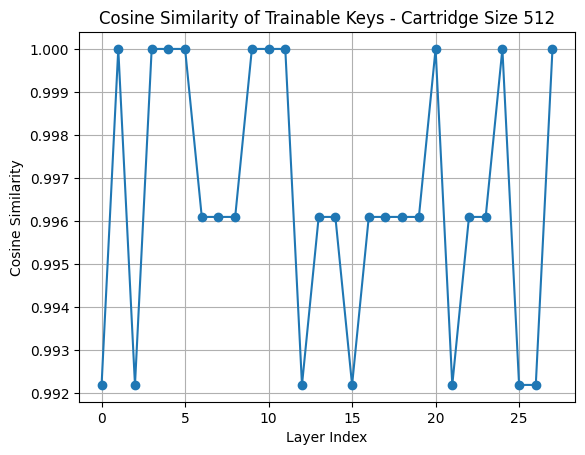

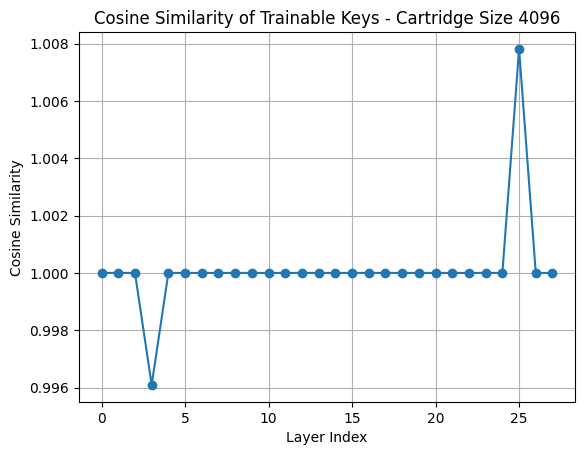

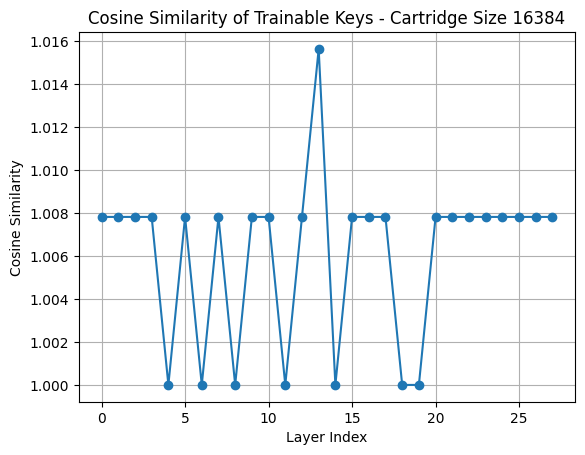

In [17]:
plot_similarity_layer(key_similarity_512, 'Trainable Keys', 512)
plot_similarity_layer(key_similarity_4096, 'Trainable Keys', 4096)
plot_similarity_layer(key_similarity_16384, 'Trainable Keys', 16384)

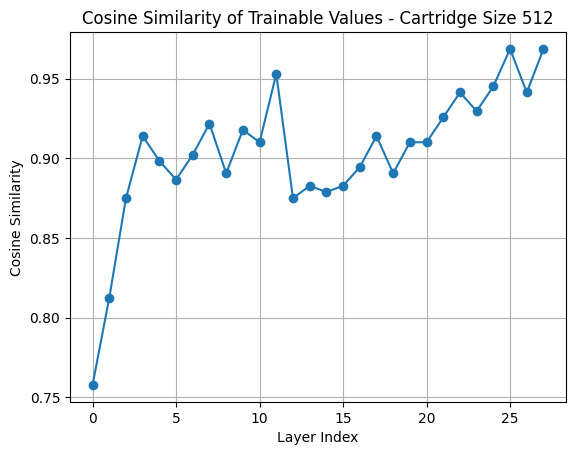

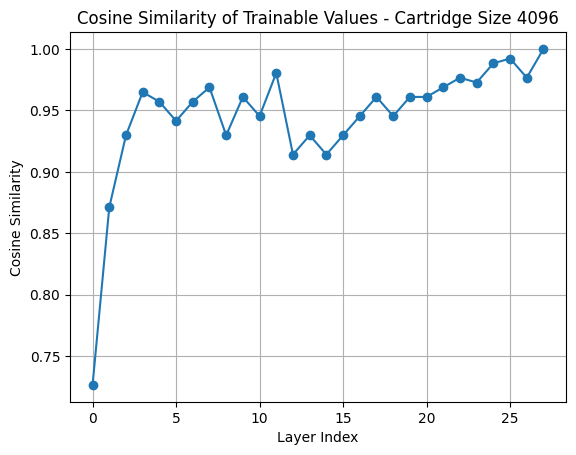

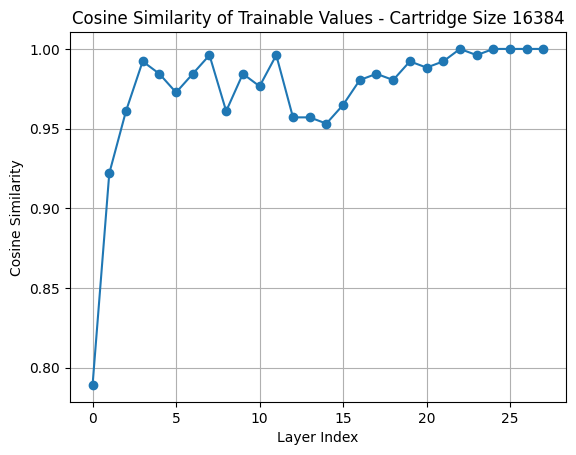

In [18]:
plot_similarity_layer(value_similarity_512, 'Trainable Values', 512)
plot_similarity_layer(value_similarity_4096, 'Trainable Values', 4096)
plot_similarity_layer(value_similarity_16384, 'Trainable Values', 16384)

In [19]:
def get_similarity_token(cartridge1, cartridge2, type):
    similarities_per_token = []
    assert type in ['trainable_keys', 'trainable_values'], f"Type must be 'trainable_keys' or 'trainable_values', got {type}"
    for layer_index in range(len(cartridge1[type])):
        first_vector = cartridge1[type][layer_index].squeeze(0).detach().float() # shape: (num_kv_heads, num_tokens, head_dim)
        first_vector = first_vector.permute(1, 0, 2)  # shape: (num_tokens, num_kv_heads, head_dim)
        first_vector = first_vector.reshape(first_vector.shape[0], -1)
        second_vector = cartridge2[type][layer_index].squeeze(0).detach().float()
        second_vector = second_vector.permute(1, 0, 2)
        second_vector = second_vector.reshape(second_vector.shape[0], -1)
        token_similarity = F.cosine_similarity(first_vector, second_vector, dim=1)
        similarities_per_token.append(token_similarity)
        torch_similarities_per_token = torch.stack(similarities_per_token)
    return torch_similarities_per_token
        

In [20]:
value_similarity_512_token = get_similarity_token(first_cartridge_512, second_cartridge_512, 'trainable_values')
value_similarity_4096_token = get_similarity_token(first_cartridge_4096, second_cartridge_4096, 'trainable_values')
value_similarity_16384_token = get_similarity_token(first_cartridge_16384, second_cartridge_16384, 'trainable_values')

In [21]:
var_value_similarity_512_token = value_similarity_512_token.var(dim=0)
var_value_similarity_4096_token = value_similarity_4096_token.var(dim=0)
var_value_similarity_16384_token = value_similarity_16384_token.var(dim=0)

In [22]:
def get_out_lier_tokens(var_value):
    threshold = var_value.mean() + 2 * var_value.std()
    outlier_indices = (var_value > threshold).nonzero().squeeze()
    return outlier_indices 

In [23]:
outlier_indices_512 = get_out_lier_tokens(var_value_similarity_512_token)
outlier_indices_4096 = get_out_lier_tokens(var_value_similarity_4096_token)
outlier_indices_16384 = get_out_lier_tokens(var_value_similarity_16384_token)

In [24]:
def plot_hist(var_value, cartridge_size):
    bins = int((cartridge_size // 100))
    plt.hist(var_value.numpy(), bins=bins, alpha=0.7)
    plt.title(f'Distribution of Outlier Tokens Based on Value Similarity Variance - Cartridge Size {cartridge_size}')
    plt.xlabel('Token Index')
    plt.ylabel('Frequency')
    plt.grid()
    plt.show()

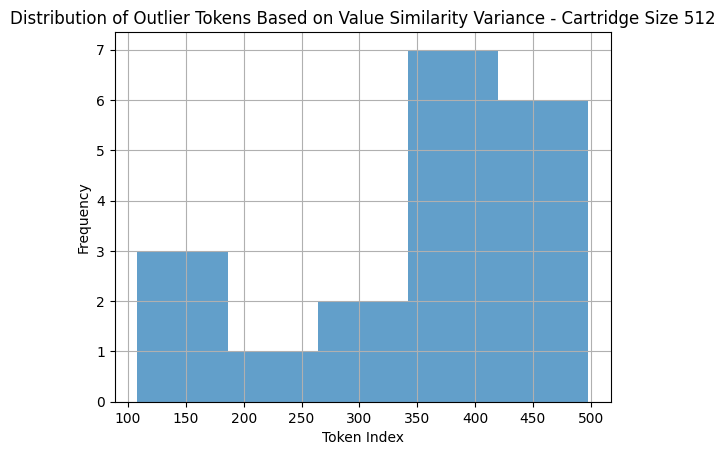

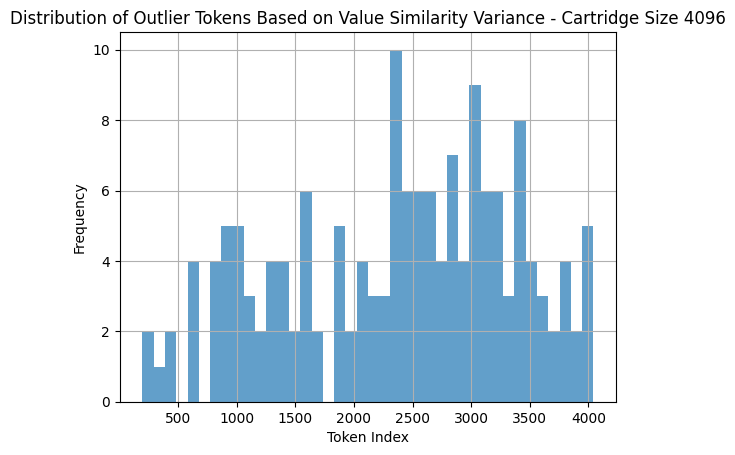

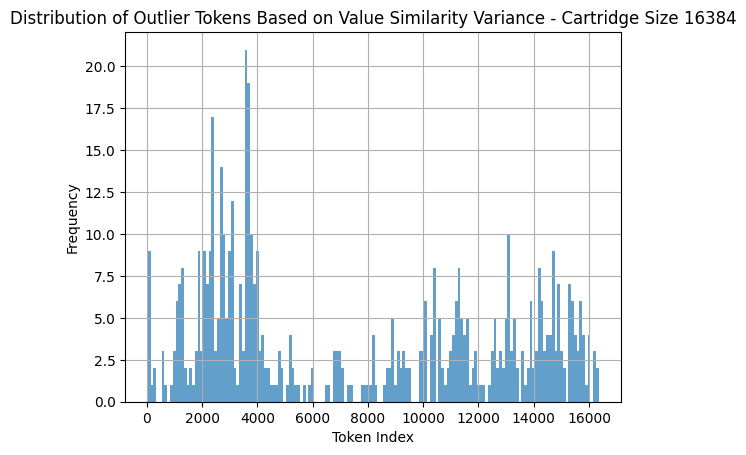

In [25]:
plot_hist(outlier_indices_512, 512)
plot_hist(outlier_indices_4096, 4096)
plot_hist(outlier_indices_16384, 16384)

In [26]:
def compute_delta_per_slot(cartridge1, cartridge2, type):
    assert type in ['trainable_keys', 'trainable_values'], f"Type must be 'trainable_keys' or 'trainable_values', got {type}"
    deltas_per_slot = []
    for layer_index in range(len(cartridge1[type])):
        first_vector = cartridge1[type][layer_index]
        second_vector = cartridge2[type][layer_index]
        delta = first_vector - second_vector
        deltas_per_slot.append(delta.squeeze(0).norm(dim=(0,-1)).detach().cpu().float())
    deltas_per_slot_tensor = torch.stack(deltas_per_slot)
    slot_delta_means = deltas_per_slot_tensor.mean(dim=0)
    return slot_delta_means

In [27]:
delta_value_512 = compute_delta_per_slot(first_cartridge_512, second_cartridge_512, 'trainable_values')
delta_value_4096 = compute_delta_per_slot(first_cartridge_4096, second_cartridge_4096, 'trainable_values')
delta_value_16384 = compute_delta_per_slot(first_cartridge_16384, second_cartridge_16384, 'trainable_values')

In [28]:
def plot_delta(delta, cartridge_size):
    plt.plot(delta.numpy(), marker='o')
    plt.title(f'Mean Delta per Slot - Cartridge Size {cartridge_size}')
    plt.xlabel('Slot Index')
    plt.ylabel('Mean Delta')
    plt.grid()
    plt.show()

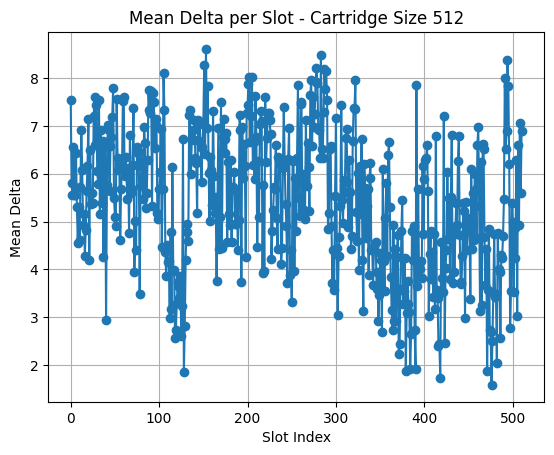

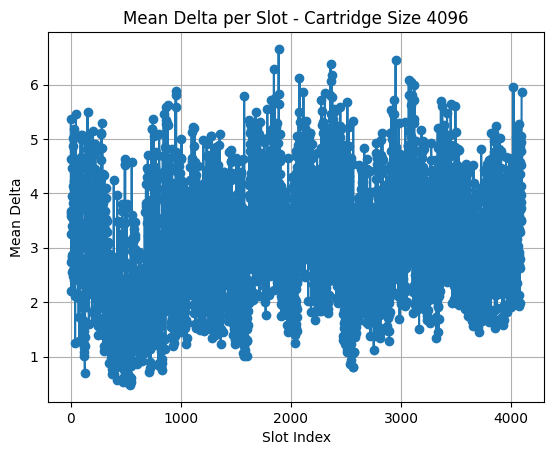

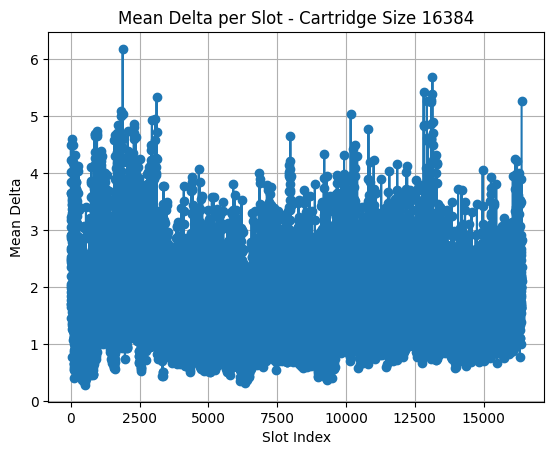

In [108]:
plot_delta(delta_value_512, 512)
plot_delta(delta_value_4096, 4096)
plot_delta(delta_value_16384, 16384)